In [1]:
# Import libraries
import os
import math
from pathlib import Path
from tqdm import tqdm
import numpy as np
import random
import time
import json
from collections import OrderedDict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, datasets, utils
from PIL import Image
import matplotlib.pyplot as plt

In [2]:
import shutil
import kagglehub

target_path = "/content/dataset"

# overwrite target folder
shutil.rmtree(target_path, ignore_errors=True)
os.makedirs(target_path, exist_ok=True)

# download
path = kagglehub.dataset_download("andrewmvd/animal-faces")
print("Downloaded to:", path)

# copy dataset into target folder
dest = os.path.join(target_path, os.path.basename(path))
shutil.copytree(path, dest, dirs_exist_ok=True)

print("Copied to:", dest)

100%|██████████| 696M/696M [00:04<00:00, 171MB/s]

Extracting files...


Downloaded to: /root/.cache/kagglehub/datasets/andrewmvd/animal-faces/versions/1
Copied to: /content/dataset/1


In [3]:
# Configuration
CFG = {
    "image_size": 128,          # pixel size (square)
    "latent_factor": 8,         # downscale factor: image_size // latent_hw = latent_hw
    "latent_channels": 4,       # number of channels in latent (lower => faster but lower fidelity)
    "batch_size": 128,
    "vae_epochs": 100,
    "diffusion_epochs": 400,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "base_channels": 128,        # UNet base channel count; increase for quality (128+)
    "timesteps": 1000,          # diffusion steps for training (we will sample with fewer steps at generation)
    "learning_rate": 2e-4,
    "ema_beta": 0.995,
    "save_dir": "./sd_tiny_checkpoints",
    "dataset_root": "/content/dataset/1/afhq/train/dog",
    "caption": "a photo of a dog",
    "seed": 42,
}

os.makedirs(CFG["save_dir"], exist_ok=True)
torch.manual_seed(CFG["seed"])
np.random.seed(CFG["seed"])
random.seed(CFG["seed"])

print("Device:", CFG["device"])

Device: cuda


In [4]:
class ImageCaptionDataset(Dataset):
    def __init__(self, root_dir, caption, image_size=128, ext=("jpg","png","jpeg")):
        self.root = Path(root_dir)
        self.paths = [p for e in ext for p in self.root.glob(f"*.{e}")]
        if len(self.paths)==0:
            raise FileNotFoundError(f"No images found in {root_dir} with extensions {ext}")
        self.caption = caption
        self.transform = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),             # [0,1]
            transforms.Normalize([0.5]*3, [0.5]*3)  # [-1,1]
        ])
    def __len__(self): return len(self.paths)
    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        img = self.transform(img)
        return img, self.caption

# Check
ds = ImageCaptionDataset(CFG["dataset_root"], CFG["caption"], image_size=CFG["image_size"])
print("Dataset length:", len(ds))
dl = DataLoader(ds, batch_size=CFG["batch_size"], shuffle=True, num_workers=2, drop_last=True)
imgs, cap = next(iter(dl))
print("Batch images shape:", imgs.shape, "Caption example:", cap)

Dataset length: 4739
Batch images shape: torch.Size([128, 3, 128, 128]) Caption example: ('a photo of a dog', 'a photo of a dog', 'a photo of a dog', 'a photo of a dog', 'a photo of a dog', 'a photo of a dog', 'a photo of a dog', 'a photo of a dog', 'a photo of a dog', 'a photo of a dog', 'a photo of a dog', 'a photo of a dog', 'a photo of a dog', 'a photo of a dog', 'a photo of a dog', 'a photo of a dog', 'a photo of a dog', 'a photo of a dog', 'a photo of a dog', 'a photo of a dog', 'a photo of a dog', 'a photo of a dog', 'a photo of a dog', 'a photo of a dog', 'a photo of a dog', 'a photo of a dog', 'a photo of a dog', 'a photo of a dog', 'a photo of a dog', 'a photo of a dog', 'a photo of a dog', 'a photo of a dog', 'a photo of a dog', 'a photo of a dog', 'a photo of a dog', 'a photo of a dog', 'a photo of a dog', 'a photo of a dog', 'a photo of a dog', 'a photo of a dog', 'a photo of a dog', 'a photo of a dog', 'a photo of a dog', 'a photo of a dog', 'a photo of a dog', 'a photo o

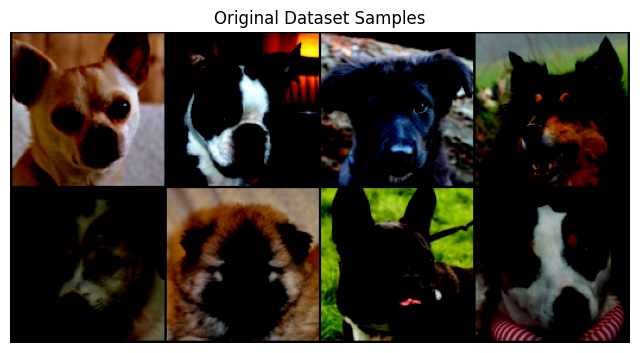

In [5]:
def show_original_samples(dataset, num=8):
    imgs = []
    for i in range(num):
        img, _ = dataset[i]
        imgs.append(img)
    grid = utils.make_grid(torch.stack(imgs), nrow=4, padding=2)
    npimg = grid.numpy().transpose(1,2,0)
    plt.figure(figsize=(8,8))
    plt.imshow(npimg)
    plt.title("Original Dataset Samples")
    plt.axis('off')
    plt.show()

show_original_samples(ds, num=8)

In [6]:
latent_hw = CFG["image_size"] // CFG["latent_factor"]

class VAE(nn.Module):
    def __init__(self, in_ch=3, base=64, latent_ch=4, latent_hw=16):
        super().__init__()
        self.latent_ch = latent_ch
        # Encoder (down to latent_hw)
        self.enc = nn.Sequential(
            nn.Conv2d(in_ch, base, 4, 2, 1), nn.SiLU(),
            nn.Conv2d(base, base*2, 4, 2, 1), nn.SiLU(),
            nn.Conv2d(base*2, base*4, 4, 2, 1), nn.SiLU(),
            nn.Conv2d(base*4, base*4, 3, 1, 1), nn.SiLU(),
        )
        # produce mu and logvar for reparam
        self.to_mu = nn.Conv2d(base*4, latent_ch, 1)
        self.to_logvar = nn.Conv2d(base*4, latent_ch, 1)
        # Decoder
        self.dec_in = nn.Conv2d(latent_ch, base*4, 3, 1, 1)
        self.dec = nn.Sequential(
            nn.ConvTranspose2d(base*4, base*2, 4, 2, 1), nn.SiLU(),
            nn.ConvTranspose2d(base*2, base, 4, 2, 1), nn.SiLU(),
            nn.ConvTranspose2d(base, in_ch, 4, 2, 1),
            nn.Tanh()  # output in [-1,1]
        )

    def encode(self, x):
        h = self.enc(x)
        mu = self.to_mu(h)
        logvar = self.to_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = (0.5 * logvar).exp()
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = self.dec_in(z)
        return self.dec(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar

# Instantiate VAE
vae = VAE(in_ch=3, base=CFG["base_channels"], latent_ch=CFG["latent_channels"], latent_hw=latent_hw).to(CFG["device"])
print(vae)

VAE(
  (enc): Sequential(
    (0): Conv2d(3, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): SiLU()
    (2): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): SiLU()
    (4): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): SiLU()
    (6): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): SiLU()
  )
  (to_mu): Conv2d(512, 4, kernel_size=(1, 1), stride=(1, 1))
  (to_logvar): Conv2d(512, 4, kernel_size=(1, 1), stride=(1, 1))
  (dec_in): Conv2d(4, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (dec): Sequential(
    (0): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): SiLU()
    (2): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): SiLU()
    (4): ConvTranspose2d(128, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): Tanh()
  )
)


In [7]:
from collections import deque
import os

class CheckpointManager:
    def __init__(self, save_dir, keep_last=2):
        self.save_dir = save_dir
        self.keep_last = keep_last
        self.queue = deque(maxlen=keep_last)

    def save(self, name, data):
        """
        name: "vae_epoch_10.pt" or "unet_epoch_50.pt"
        data: checkpoint dictionary
        """
        path = os.path.join(self.save_dir, name)
        torch.save(data, path)

        # add to queue (if full, oldest is automatically removed)
        if len(self.queue) == self.keep_last:
            old = self.queue[0]
            old_path = os.path.join(self.save_dir, old)
            if os.path.exists(old_path):
                os.remove(old_path)

        self.queue.append(name)
        print(f"Saved {name} (kept {len(self.queue)}/{self.keep_last})")

In [8]:
vae_manager = CheckpointManager(CFG["save_dir"], keep_last=2)
ldm_manager = CheckpointManager(CFG["save_dir"], keep_last=2)

In [10]:
opt_vae = torch.optim.Adam(vae.parameters(), lr=CFG["learning_rate"] * 0.5)

def vae_loss(recon_x, x, mu, logvar, recon_weight=1.0, kl_weight=0.0005):
    recon = F.mse_loss(recon_x, x)
    # KL divergence between q(z|x) and N(0,1)
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / (x.shape[0]*x.shape[2]*x.shape[3])
    return recon*recon_weight + kl*kl_weight, recon.item(), kl.item()

print("Pretraining VAE (small epochs for example).")
for epoch in range(CFG["vae_epochs"]):
    pbar = tqdm(dl, desc=f"VAE Epoch {epoch+1}/{CFG['vae_epochs']}")
    running_loss = 0.0
    for imgs, captions in pbar:
        imgs = imgs.to(CFG["device"])
        opt_vae.zero_grad()
        recon, mu, logvar = vae(imgs)
        loss, recon_l, kl_l = vae_loss(recon, imgs, mu, logvar)
        loss.backward()
        opt_vae.step()
        running_loss += loss.item()
        pbar.set_postfix({'loss': running_loss/(pbar.n+1), 'recon': recon_l, 'kl': kl_l})
    # save intermediate VAE
    vae_ckpt = {
    "epoch": epoch + 1,
    "vae": vae.state_dict(),
    "opt_vae": opt_vae.state_dict()
        }
    vae_manager.save(f"vae_epoch_{epoch+1}.pt", vae_ckpt)

print("VAE pretrain complete.")

Pretraining VAE (small epochs for example).


VAE Epoch 1/100: 100%|██████████| 37/37 [00:25<00:00,  1.42it/s, loss=0.0595, recon=0.0451, kl=0.396]


Saved vae_epoch_1.pt (kept 1/2)


VAE Epoch 2/100: 100%|██████████| 37/37 [00:26<00:00,  1.40it/s, loss=0.0393, recon=0.0355, kl=0.409]


Saved vae_epoch_2.pt (kept 2/2)


...

Saved vae_epoch_98.pt (kept 2/2)


VAE Epoch 99/100: 100%|██████████| 37/37 [00:27<00:00,  1.36it/s, loss=0.00796, recon=0.00743, kl=0.279]


Saved vae_epoch_99.pt (kept 2/2)


VAE Epoch 100/100: 100%|██████████| 37/37 [00:27<00:00,  1.36it/s, loss=0.008, recon=0.00863, kl=0.28]

Saved vae_epoch_100.pt (kept 2/2)
VAE pretrain complete.


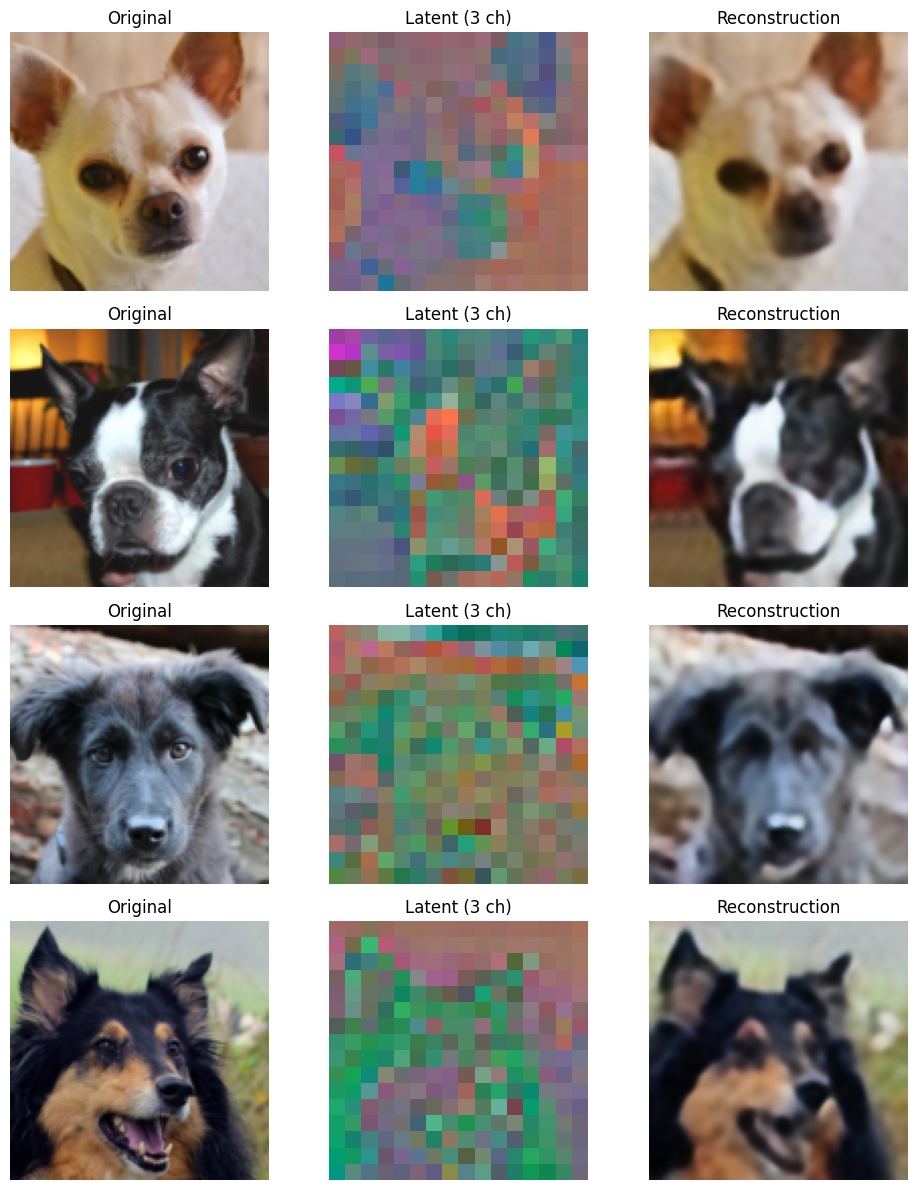

In [11]:
@torch.no_grad()
def visualize_vae_process(vae, dataset, num_samples=4):
    vae.eval()

    imgs = []
    for i in range(num_samples):
        img, _ = dataset[i]
        imgs.append(img)
    imgs = torch.stack(imgs).to(CFG["device"])

    # Encode → get mu, logvar → sample z
    mu, logvar = vae.encode(imgs)
    z = vae.reparameterize(mu, logvar)

    # Decode from latent
    recon = vae.decode(z)

    # Convert for plotting
    imgs_plot = (imgs.cpu().clamp(-1,1) + 1) / 2
    recon_plot = (recon.cpu().clamp(-1,1) + 1) / 2

    # Latent visualization (use 3 channels only)
    lat = z[:, :3, :, :].detach().cpu()
    lat = (lat - lat.min()) / (lat.max() - lat.min() + 1e-8)

    # Plot
    plt.figure(figsize=(10, num_samples * 3))
    for i in range(num_samples):
        # original
        plt.subplot(num_samples, 3, i*3 + 1)
        plt.imshow(imgs_plot[i].permute(1,2,0))
        plt.title("Original")
        plt.axis("off")

        # latent
        plt.subplot(num_samples, 3, i*3 + 2)
        plt.imshow(lat[i].permute(1,2,0))
        plt.title("Latent (3 ch)")
        plt.axis("off")

        # reconstruction
        plt.subplot(num_samples, 3, i*3 + 3)
        plt.imshow(recon_plot[i].permute(1,2,0))
        plt.title("Reconstruction")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

visualize_vae_process(vae, ds, num_samples=4)

In [12]:
#Utility: encode images to latents and compute scale factor (std)
def encode_batch_to_latents(model, x):
    model.eval()
    with torch.no_grad():
        mu, logvar = model.encode(x)
        z = mu  # use mean for encoding, similar to Stable Diffusion's encoder
    return z

# compute latent std across a few batches to normalize
print("Computing latent std (scale factor)...")
all_z = []
count = 0
for imgs, _ in dl:
    imgs = imgs.to(CFG["device"])
    z = encode_batch_to_latents(vae, imgs)
    all_z.append(z.detach().cpu().numpy())
    count += 1
    if count >= 10:
        break
all_z = np.concatenate(all_z, axis=0)
latent_std = np.std(all_z)
scale_factor = 1.0 / (latent_std + 1e-8)
print("latent std:", latent_std, "scale_factor:", scale_factor)

Computing latent std (scale factor)...
latent std: 1.42061 scale_factor: 0.703923


In [13]:
try:
    from transformers import CLIPTokenizer, CLIPTextModel
    clip_model_name = "openai/clip-vit-base-patch32"
    print("Attempting to load CLIP tokenizer and text model:", clip_model_name)
    tokenizer = CLIPTokenizer.from_pretrained(clip_model_name)
    text_encoder = CLIPTextModel.from_pretrained(clip_model_name).to(CFG["device"])
    is_clip = True
    print("Loaded CLIP text encoder.")
except Exception as e:
    print("CLIP unavailable:", e)
    print("Falling back to sentence-transformers (may be slower and produce different conditioning).")
    from sentence_transformers import SentenceTransformer
    ste = SentenceTransformer("all-MiniLM-L6-v2")
    # wrapper to standardize API (produce torch.Tensor)
    class STWrapper:
        def __init__(self, model): self.model = model
        def encode(self, texts, device="cpu"):
            arr = self.model.encode(list(texts), convert_to_numpy=True)
            return torch.tensor(arr, dtype=torch.float32).to(device)
    tokenizer = None
    text_encoder = STWrapper(ste)
    is_clip = False

# helper to get text embeddings; also able to create empty embedding for classifier-free guidance
def get_text_embeddings(texts, device=CFG["device"], max_length=77):
    if is_clip:
        # returns [B, seq_len, dim], we will pool to mean or use last hidden state
        tokens = tokenizer(texts, padding="longest", truncation=True, return_tensors="pt").to(device)
        with torch.no_grad():
            outputs = text_encoder(**tokens, return_dict=True)
            # CLIPTextModel returns last_hidden_state (B, L, D)
            return outputs.last_hidden_state  # token-level embeddings
    else:
        # SentenceTransformer: returns (B, dim) -> expand to (B,1,dim) for compatibility
        emb = text_encoder.encode(texts, device=device)
        return emb.unsqueeze(1)  # [B, 1, dim]

Attempting to load CLIP tokenizer and text model: openai/clip-vit-base-patch32


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
visual_projection.weight             

Loaded CLIP text encoder.


In [14]:
class TimestepEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
    def forward(self, t):
        # t: (B,) ints
        half = self.dim // 2
        freqs = torch.exp(-math.log(10000) * torch.arange(0, half, dtype=torch.float32) / half).to(t.device)
        args = t[:, None].float() * freqs[None, :]
        emb = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)
        return emb  # [B, dim]

In [15]:
class ResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, t_dim, c_dim):
        super().__init__()
        self.norm1 = nn.GroupNorm(8, in_ch)
        self.act = nn.SiLU()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.norm2 = nn.GroupNorm(8, out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
        self.t_proj = nn.Linear(t_dim, out_ch)
        self.c_proj = nn.Linear(c_dim, out_ch)

    def forward(self, x, t_emb, c_emb):
        h = self.norm1(x)
        h = self.act(h)
        h = self.conv1(h)
        # add time and class-conditioning
        h = h + self.t_proj(t_emb)[:, :, None, None]
        h = h + self.c_proj(c_emb)[:, :, None, None]
        h = self.norm2(h)
        h = self.act(h)
        h = self.conv2(h)
        return self.skip(x) + h

class CrossAttention(nn.Module):
    def __init__(self, channels, context_dim, num_heads=4):
        super().__init__()
        self.num_heads = num_heads
        self.scale = (channels // num_heads) ** -0.5
        self.to_q = nn.Conv2d(channels, channels, 1)
        self.to_k = nn.Linear(context_dim, channels)
        self.to_v = nn.Linear(context_dim, channels)
        self.to_out = nn.Conv2d(channels, channels, 1)

    def forward(self, x, context):
        # x: [B, C, H, W]; context: [B, L, D] or [B, 1, D]
        b, c, h, w = x.shape
        n = h*w
        q = self.to_q(x).view(b, self.num_heads, c//self.num_heads, n)  # [B, heads, d, N]
        q = q.permute(0,1,3,2)  # [B,heads,N,d]
        k = self.to_k(context)  # [B, L, C]
        v = self.to_v(context)  # [B, L, C]
        k = k.view(b, -1, self.num_heads, c//self.num_heads).permute(0,2,1,3)  # [B,heads,L,d]
        v = v.view(b, -1, self.num_heads, c//self.num_heads).permute(0,2,1,3)
        attn = torch.matmul(q, k.transpose(-2,-1)) * self.scale  # [B,heads,N,L]
        attn = torch.softmax(attn, dim=-1)
        out = torch.matmul(attn, v)  # [B,heads,N,d]
        out = out.permute(0,1,3,2).contiguous().view(b, c, n)  # [B, C, N]
        out = out.view(b, c, h, w)
        out = self.to_out(out)
        return x + out

class TinyUNet(nn.Module):
    def __init__(self, latent_ch, base_ch, t_dim, text_dim):
        super().__init__()
        self.in_conv = nn.Conv2d(latent_ch, base_ch, 3, padding=1)
        # down
        self.res1 = ResidualBlock(base_ch, base_ch, t_dim, text_dim)
        self.down1 = nn.Conv2d(base_ch, base_ch*2, 4, 2, 1)
        self.res2 = ResidualBlock(base_ch*2, base_ch*2, t_dim, text_dim)
        self.down2 = nn.Conv2d(base_ch*2, base_ch*4, 4, 2, 1)
        self.res3 = ResidualBlock(base_ch*4, base_ch*4, t_dim, text_dim)
        # bottleneck
        self.mid = ResidualBlock(base_ch*4, base_ch*4, t_dim, text_dim)
        self.cross_attn = CrossAttention(base_ch*4, text_dim, num_heads=4)
        # up
        self.up1 = nn.ConvTranspose2d(base_ch*4, base_ch*2, 4, 2, 1)
        self.res_up1 = ResidualBlock(base_ch*2, base_ch*2, t_dim, text_dim)
        self.up2 = nn.ConvTranspose2d(base_ch*2, base_ch, 4, 2, 1)
        self.res_up2 = ResidualBlock(base_ch, base_ch, t_dim, text_dim)
        self.out_conv = nn.Conv2d(base_ch, latent_ch, 3, padding=1)

    def forward(self, z, t_emb, text_emb):
        # z: [B,C,H,W]; t_emb: [B,t_dim]; text_emb: [B,L,D] or [B,1,D]
        x = self.in_conv(z)
        x1 = self.res1(x, t_emb, text_emb.mean(dim=1) if text_emb.ndim==3 else text_emb.squeeze(1))
        x = self.down1(x1)
        x2 = self.res2(x, t_emb, text_emb.mean(dim=1) if text_emb.ndim==3 else text_emb.squeeze(1))
        x = self.down2(x2)
        x = self.res3(x, t_emb, text_emb.mean(dim=1) if text_emb.ndim==3 else text_emb.squeeze(1))
        x = self.mid(x, t_emb, text_emb.mean(dim=1) if text_emb.ndim==3 else text_emb.squeeze(1))
        # cross-attend to text tokens
        x = self.cross_attn(x, text_emb)
        x = self.up1(x)
        # skip connection
        x = x + x2
        x = self.res_up1(x, t_emb, text_emb.mean(dim=1) if text_emb.ndim==3 else text_emb.squeeze(1))
        x = self.up2(x)
        x = x + x1
        x = self.res_up2(x, t_emb, text_emb.mean(dim=1) if text_emb.ndim==3 else text_emb.squeeze(1))
        out = self.out_conv(x)
        return out

# instantiate UNet

if is_clip:
    text_dim = text_encoder.config.hidden_size      # CLIP = 768
else:
    # SentenceTransformer pooled embedding size
    text_dim = text_encoder.model.get_sentence_embedding_dimension()

print("Detected text embedding dimension:", text_dim)

t_dim = 256  # time embedding

unet = TinyUNet(
    latent_ch=CFG["latent_channels"],
    base_ch=CFG["base_channels"],
    t_dim=t_dim,
    text_dim=text_dim
).to(CFG["device"])

print("UNet initialized with text_dim =", text_dim)

Detected text embedding dimension: 512
UNet initialized with text_dim = 512


In [16]:
T = CFG["timesteps"]
betas = np.linspace(1e-4, 0.02, T, dtype=np.float32)
alphas = 1.0 - betas
alpha_cum = np.cumprod(alphas, axis=0)

def q_sample(z0, t, noise):
    # z0, noise: [B,C,H,W]; t: [B] int indices 0..T-1
    a = torch.tensor(alpha_cum, dtype=torch.float32, device=z0.device)[t]  # [B]
    a = a.view(-1, 1, 1, 1)
    return torch.sqrt(a) * z0 + torch.sqrt(1 - a) * noise

def sample_timesteps(batch_size):
    return np.random.randint(0, T, size=(batch_size,))

# simple linear schedule helpers for reverse step
alphas_torch = torch.tensor(alphas, dtype=torch.float32, device=CFG["device"])
alpha_cum_torch = torch.tensor(alpha_cum, dtype=torch.float32, device=CFG["device"])

In [17]:
class EMA:
    def __init__(self, model, beta=0.995):
        self.beta = beta
        self.model = model
        self.shadow = {}
        self.backup = {}

    def register(self):
        for name, param in self.model.named_parameters():
            if param.requires_grad:
                self.shadow[name] = param.data.clone()

    def update(self):
        for name, param in self.model.named_parameters():
            if param.requires_grad:
                assert name in self.shadow
                new_avg = (1.0 - self.beta) * param.data + self.beta * self.shadow[name]
                self.shadow[name] = new_avg.clone()

    def apply_shadow(self):
        for name, param in self.model.named_parameters():
            if param.requires_grad:
                self.backup[name] = param.data.clone()
                param.data = self.shadow[name]

    def restore(self):
        for name, param in self.model.named_parameters():
            if param.requires_grad:
                param.data = self.backup[name]
        self.backup = {}

In [18]:
opt = torch.optim.Adam(unet.parameters(), lr=CFG["learning_rate"])
ema = EMA(unet, beta=CFG["ema_beta"])
ema.register()

# classifier-free guidance: during training, occasionally replace text with empty token
cf_prob = 0.1  # probability to drop conditioning during training

def train_diffusion(epochs=10, dataloader=None):
    unet.train()
    for ep in range(epochs):
        pbar = tqdm(dataloader, desc=f"Diffusion Epoch {ep+1}/{epochs}")
        for imgs, captions in pbar:
            imgs = imgs.to(CFG["device"])
            # encode to latent (use mean mu), and scale
            mu, logvar = vae.encode(imgs)
            z0 = mu * scale_factor  # scale latent
            B = z0.shape[0]
            ts = sample_timesteps(B)
            ts_t = torch.tensor(ts, device=CFG["device"], dtype=torch.long)
            noise = torch.randn_like(z0)
            zt = q_sample(z0, ts_t, noise)
            # prepare text embeddings (classifier-free: sometimes feed empty)
            if is_clip:
                texts = list(captions)
            else:
                texts = list(captions)
            # decide which indices to drop conditioning
            cf_mask = (torch.rand(B) < cf_prob).to(CFG["device"])
            texts_cond = []
            for i in range(B):
                texts_cond.append("" if cf_mask[i] else texts[i])
            text_emb = get_text_embeddings(texts_cond, device=CFG["device"])
            # time embeddings
            t_emb = TimestepEmbedding(t_dim).to(CFG["device"])(ts_t)
            # forward predict noise
            pred_noise = unet(zt, t_emb, text_emb)
            loss = F.mse_loss(pred_noise, noise)
            opt.zero_grad()
            loss.backward()
            opt.step()
            ema.update()
            pbar.set_postfix({'loss': loss.item()})
        # checkpoint
        ldm_ckpt = {"epoch": ep+1,"unet": unet.state_dict(),"opt_unet": opt.state_dict(),
                    "ema_shadow": ema.shadow,"scale_factor": scale_factor}
        ldm_manager.save(f"unet_epoch_{ep+1}.pt", ldm_ckpt)

        # optional: save EMA shadow weights separately
        np.save(os.path.join(CFG["save_dir"], "ema_shadow.npy"), ema.shadow)
    print("Diffusion training finished.")

In [19]:
@torch.no_grad()
def ddim_sample(unet_model, text_prompt, num_samples=4, steps=50, eta=0.0):
    device = CFG["device"]
    unet_model.eval()
    # prepare conditioning
    texts = [text_prompt]*num_samples
    text_emb = get_text_embeddings(texts, device=device)
    # start from Gaussian noise at latent scale
    z = torch.randn(num_samples, CFG["latent_channels"], latent_hw, latent_hw, device=device)
    z = z  # already standard normal
    # precompute schedule for DDIM (we use alpha_cum)
    seq = np.linspace(T-1, 0, steps, dtype=int)
    for i in range(len(seq)):
        t = seq[i]
        t_batch = torch.tensor([t]*num_samples, device=device, dtype=torch.long)
        t_emb = TimestepEmbedding(t_dim).to(device)(t_batch)
        eps_pred = unet_model(z * 1.0, t_emb, text_emb)  # predict noise
        a_t = alpha_cum_torch[t]
        if i == len(seq)-1:
            a_next = torch.tensor(1.0, device=device)
        else:
            a_next = alpha_cum_torch[seq[i+1]]
        # DDIM update (equations adapted to latent-space)
        pred_x0 = (z - torch.sqrt(1 - a_t) * eps_pred) / torch.sqrt(a_t)
        dir_part = torch.sqrt(1 - a_next) * eps_pred
        z = torch.sqrt(a_next) * pred_x0 + dir_part
    # after sampling, reverse scale and decode
    z_dec = z / scale_factor
    imgs = vae.decode(z_dec).cpu()
    imgs = (imgs.clamp(-1,1) + 1) / 2.0  # [-1,1] -> [0,1]
    return imgs

# Quick visualization utility
def show_grid(tensor_imgs, nrow=4, figsize=(8,8), title=None):
    grid = utils.make_grid(tensor_imgs, nrow=nrow)
    npimg = grid.numpy().transpose(1,2,0)
    plt.figure(figsize=figsize)
    plt.imshow(npimg)
    plt.axis('off')
    if title: plt.title(title)
    plt.show()


Diffusion Epoch 1/400: 100%|██████████| 37/37 [00:33<00:00,  1.10it/s, loss=0.326]


Saved unet_epoch_1.pt (kept 1/2)


Diffusion Epoch 2/400: 100%|██████████| 37/37 [00:24<00:00,  1.51it/s, loss=0.29]


Saved unet_epoch_2.pt (kept 2/2)


Diffusion Epoch 3/400: 100%|██████████| 37/37 [00:23<00:00,  1.55it/s, loss=0.243]


...

Saved unet_epoch_398.pt (kept 2/2)


Diffusion Epoch 399/400: 100%|██████████| 37/37 [00:23<00:00,  1.56it/s, loss=0.158]


Saved unet_epoch_399.pt (kept 2/2)


Diffusion Epoch 400/400: 100%|██████████| 37/37 [00:23<00:00,  1.55it/s, loss=0.14]


Saved unet_epoch_400.pt (kept 2/2)
Diffusion training finished.


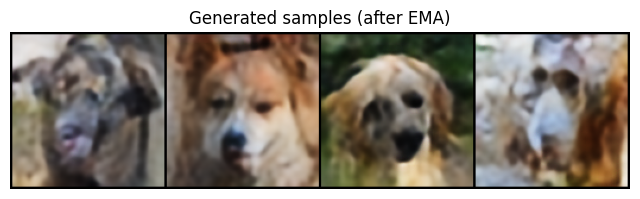

In [20]:
# === TRAIN UNET ===
train_diffusion(epochs=CFG['diffusion_epochs'], dataloader=dl)

# === USE EMA FOR SAMPLING ===
ema.apply_shadow()

# === GENERATE IMAGES ===
samples = ddim_sample(unet, CFG['caption'], num_samples=4, steps=50)

# === SHOW RESULTS ===
show_grid(samples, nrow=4, title="Generated samples (after EMA)")

# === RESTORE ORIGINAL WEIGHTS (optional) ===
ema.restore()

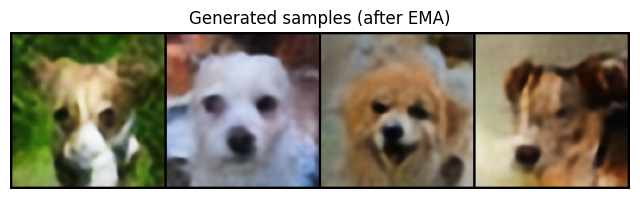

In [26]:
# === USE EMA FOR SAMPLING ===
ema.apply_shadow()

# === GENERATE IMAGES ===
samples = ddim_sample(unet, CFG['caption'], num_samples=4, steps=50)

# === SHOW RESULTS ===
show_grid(samples, nrow=4, title="Generated samples (after EMA)")

# === RESTORE ORIGINAL WEIGHTS (optional) ===
ema.restore()